# 05 · P4 — 취향 네트워크 매칭 가능성 (위시리스트 90% 커버리지)

위시 크롤 확장(커버리지 8.6%→90.3%, owners 10,023 / wishlist 277,651행)으로
P4("죽은 재고를 취향 맞는 구매자에게 매칭")를 본격 검증한다.

**핵심 질문:** 셀러 노력이 13%뿐(H2)이라면 레버는 매칭이다. 그렇다면
**묵은 재고에 도달 가능한 '관심 구매자 풀'이 실제로 존재하는가?** = P4의 실현가능성.

In [1]:
import json, sqlite3
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
matplotlib.rcParams["font.family"] = "AppleGothic"; matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
FIG = ROOT / "results" / "figures"; CACHE = ROOT / "data" / "cache"

with sqlite3.connect(ROOT / "data" / "fruitsfamily.db") as conn:
    wl = pd.read_sql_query("SELECT owner_seller_id, product_id FROM wishlist", conn)
    prod = pd.read_sql_query("SELECT product_id, brand, seller_id FROM listing", conn)
    n_sellers = conn.execute("SELECT COUNT(*) FROM seller").fetchone()[0]
lst = pd.read_parquet(CACHE / "features_listing.parquet")
clusters = pd.read_parquet(CACHE / "seller_clusters.parquet")

# 위시 → 브랜드/원셀러 매핑
wl = wl.merge(prod, on="product_id", how="left")
mapped = wl.dropna(subset=["brand"])
print(f"위시 owners {wl.owner_seller_id.nunique():,} | rows {len(wl):,} | 브랜드매핑 {len(mapped):,} ({len(mapped)/len(wl):.0%})")

위시 owners 10,023 | rows 277,651 | 브랜드매핑 93,731 (34%)


## 1. 취향은 구조적인가 (랜덤이 아니라 집중돼 있나) + 셀러 간 신호인가

In [2]:
# 셀러별 위시 브랜드 집중도(HHI)
def hhi(s):
    p = s.value_counts(normalize=True); return (p**2).sum()
taste_hhi = mapped.groupby("owner_seller_id")["brand"].agg(hhi)
cross = (mapped["seller_id"] != mapped["owner_seller_id"]).mean()
print(f"위시 브랜드 HHI 중앙값: {taste_hhi.median():.3f}  (높을수록 취향 집중)")
print(f"타 셀러 매물 찜 비율(취향=수요 신호): {cross:.1%}")
print(f"셀러당 위시 고유 브랜드 수 중앙값: {mapped.groupby('owner_seller_id')['brand'].nunique().median():.0f}")

위시 브랜드 HHI 중앙값: 0.222  (높을수록 취향 집중)
타 셀러 매물 찜 비율(취향=수요 신호): 75.5%
셀러당 위시 고유 브랜드 수 중앙값: 6


## 2. 브랜드 수요 지수 — 각 브랜드를 찜한 '고유 구매자(셀러)' 수

이게 매칭의 연료: 어떤 브랜드를 원하는 사람이 네트워크에 몇 명 있나.

In [3]:
brand_demand = mapped.groupby("brand")["owner_seller_id"].nunique().rename("n_wishers")
print(f"수요 지수 보유 브랜드: {len(brand_demand):,}")
print("\n수요 상위 10 브랜드(찜한 고유 셀러 수):")
print(brand_demand.sort_values(ascending=False).head(10).to_string())

수요 지수 보유 브랜드: 3,453

수요 상위 10 브랜드(찜한 고유 셀러 수):
brand
Prada                1200
Maison Margiela      1118
Stone Island         1064
Vintage              1043
Levi's                914
Chrome Hearts         812
Supreme               806
Rick Owens            802
Polo Ralph Lauren     739
Comme des Garcons     737


## 3. ★ 죽은 재고 매칭 가능성 — 묵은 매물에 도달 가능한 관심 풀이 있나

90일+ 미판매 매물의 브랜드를 원하는(찜한) 고유 셀러가 네트워크에 몇 명인지.

  브랜드 관심자 ≥ 1명: 98.3% of 죽은재고
  브랜드 관심자 ≥ 5명: 94.1% of 죽은재고
  브랜드 관심자 ≥20명: 85.4% of 죽은재고
  브랜드 관심자 ≥50명: 73.9% of 죽은재고

  죽은재고 브랜드 관심자 수 중앙값: 190
  관심자 0명(매칭 불가): 1.7%


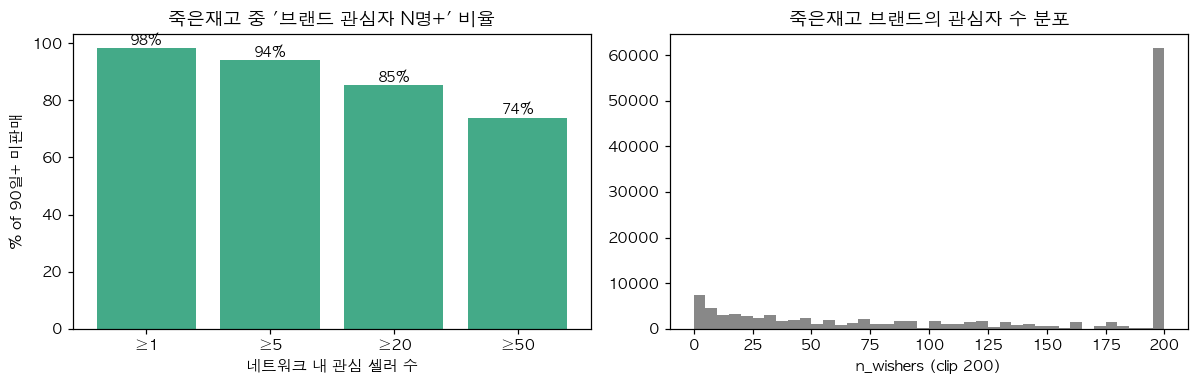

In [4]:
dead = lst[(lst.is_sold == 0) & (lst.age_days >= 90)].copy()
dead = dead.merge(brand_demand, on="brand", how="left")
dead["n_wishers"] = dead["n_wishers"].fillna(0)

for thr in [1, 5, 20, 50]:
    print(f"  브랜드 관심자 ≥{thr:>2}명: {(dead.n_wishers >= thr).mean():.1%} of 죽은재고")
print(f"\n  죽은재고 브랜드 관심자 수 중앙값: {dead.n_wishers.median():.0f}")
print(f"  관심자 0명(매칭 불가): {(dead.n_wishers == 0).mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
shares = [(dead.n_wishers >= t).mean()*100 for t in [1, 5, 20, 50]]
ax[0].bar([f"≥{t}" for t in [1,5,20,50]], shares, color="#4a8")
ax[0].set(title="죽은재고 중 '브랜드 관심자 N명+' 비율", ylabel="% of 90일+ 미판매", xlabel="네트워크 내 관심 셀러 수")
for i,v in enumerate(shares): ax[0].text(i, v+1, f"{v:.0f}%", ha="center", fontsize=9)
ax[1].hist(np.clip(dead.n_wishers, 0, 200), bins=40, color="#888")
ax[1].set(title="죽은재고 브랜드의 관심자 수 분포", xlabel="n_wishers (clip 200)")
fig.tight_layout(); fig.savefig(FIG / "p4_matchability.png", bbox_inches="tight"); plt.show()

## 4. 아키타입 동질성 — 같은 판매 아키타입끼리 취향도 닮았나

같으면: 아키타입이 매칭 코호트의 프록시가 됨. 다르면: 취향은 판매유형과 독립 신호.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize

owners = mapped.groupby("owner_seller_id")["brand"].apply(lambda s: " ".join(s.astype(str)))
om = owners.reset_index().merge(clusters, left_on="owner_seller_id", right_on="seller_id", how="inner")
X = normalize(CountVectorizer(max_features=500).fit_transform(om["brand"]))
arch = om["archetype"].values

rng = np.random.RandomState(0)
def sample_sim(same):
    sims = []
    for _ in range(4000):
        i, j = rng.randint(0, X.shape[0], 2)
        if i == j: continue
        if (arch[i] == arch[j]) != same: continue
        sims.append(float(X[i].multiply(X[j]).sum()))
    return np.mean(sims) if sims else np.nan
within = sample_sim(True); across = sample_sim(False)
print(f"위시 취향 코사인 유사도 — 같은 아키타입: {within:.3f} vs 다른 아키타입: {across:.3f}")
print(f"동질성 비율: {within/across:.2f}x" if across else "")

위시 취향 코사인 유사도 — 같은 아키타입: 0.047 vs 다른 아키타입: 0.039
동질성 비율: 1.21x


## 5. 결과 저장

In [6]:
res = {
    "coverage": {"owners": int(wl.owner_seller_id.nunique()),
                 "owner_pct_of_all_sellers": round(wl.owner_seller_id.nunique()/n_sellers, 3),
                 "wishlist_rows": int(len(wl)), "brand_mapped_rows": int(len(mapped))},
    "taste_structure": {"brand_hhi_median": round(float(taste_hhi.median()), 3),
                        "cross_seller_pct": round(float(cross), 3)},
    "dead_stock_matchability": {
        "median_wishers_of_brand": float(dead.n_wishers.median()),
        "pct_ge_1": round(float((dead.n_wishers >= 1).mean()), 3),
        "pct_ge_5": round(float((dead.n_wishers >= 5).mean()), 3),
        "pct_ge_20": round(float((dead.n_wishers >= 20).mean()), 3),
        "pct_unmatchable_0": round(float((dead.n_wishers == 0).mean()), 3)},
    "archetype_taste_homophily": {"within": round(float(within), 3), "across": round(float(across), 3),
                                  "ratio": round(float(within/across), 2) if across else None},
    "top_demand_brands": brand_demand.sort_values(ascending=False).head(10).astype(int).to_dict(),
}
(ROOT / "results" / "p4_taste_network.json").write_text(
    json.dumps(res, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(res, ensure_ascii=False, indent=2))

{
  "coverage": {
    "owners": 10023,
    "owner_pct_of_all_sellers": 0.903,
    "wishlist_rows": 277651,
    "brand_mapped_rows": 93731
  },
  "taste_structure": {
    "brand_hhi_median": 0.222,
    "cross_seller_pct": 0.755
  },
  "dead_stock_matchability": {
    "median_wishers_of_brand": 190.0,
    "pct_ge_1": 0.983,
    "pct_ge_5": 0.941,
    "pct_ge_20": 0.854,
    "pct_unmatchable_0": 0.017
  },
  "archetype_taste_homophily": {
    "within": 0.047,
    "across": 0.039,
    "ratio": 1.21
  },
  "top_demand_brands": {
    "Prada": 1200,
    "Maison Margiela": 1118,
    "Stone Island": 1064,
    "Vintage": 1043,
    "Levi's": 914,
    "Chrome Hearts": 812,
    "Supreme": 806,
    "Rick Owens": 802,
    "Polo Ralph Lauren": 739,
    "Comme des Garcons": 737
  }
}
